In [223]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import KFold

import matplotlib.pyplot as plt

In this homework, we will use the Bank Marketing dataset. Download it from [here](https://archive.ics.uci.edu/static/public/222/bank+marketing.zip).

You can do it with `wget`:

```bash
wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
unzip bank+marketing.zip 
unzip bank.zip
```

We need `bank-full.csv`.

In this dataset the target variable is `y` variable - has the client subscribed a term deposit or not. 

### Dataset preparation

For the rest of the homework, you'll need to use only these columns:

* `'age'`,
* `'job'`,
* `'marital'`,
* `'education'`,
* `'balance'`,
* `'housing'`,
* `'contact'`,
* `'day'`,
* `'month'`,
* `'duration'`,
* `'campaign'`,
* `'pdays'`,
* `'previous'`,
* `'poutcome'`,
* `'y'`



Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`

In [69]:
cols = ['age',
'job',
'marital',
'education',
'balance',
'housing',
'contact',
'day',
'month',
'duration',
'campaign',
'pdays',
'previous',
'poutcome',
'y']

In [70]:
df = pd.read_csv('bank-full.csv', sep=';', usecols=cols)

In [71]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no


In [72]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [73]:
df['y' ]= df['y'].map({'no': 0, 'yes': 1})

In [74]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

target = 'y'
y_full_train = df_full_train[target].values
y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

del df_full_train[target]
del df_train[target]
del df_val[target]
del df_test[target]

assert len(df_train) == len(y_train)
assert len(df_val) == len(y_val)
assert len(df_test) == len(y_test)

In [75]:
len(df_train), len(df_val), len(df_test)

(27126, 9042, 9043)

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score and compute AUC with the `y` variable
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['engine_hp']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `balance`
- `day`
- `duration`
- `previous`

In [76]:
numerical = [f for f in df.columns if df[f].dtype != object]
numerical

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']

In [77]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

In [78]:
def calc_fi_roc(feature, df, y=y_train):
    auc = roc_auc_score(y_train, df[feature])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df[feature])
    return auc

In [79]:
for f in ['balance', 'day', 'duration', 'previous']:
    fi = calc_fi_roc(f, df_train, y_train)
    print(f"{f}, ---> auc_fi: {fi:0.5f}")

balance, ---> auc_fi: 0.58883
day, ---> auc_fi: 0.52596
duration, ---> auc_fi: 0.81470
previous, ---> auc_fi: 0.59857


answer: duration

### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.69
- 0.79
- 0.89
- 0.99

In [80]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [85]:
dv = DictVectorizer(sparse=False)

dicts_train = df_train.to_dict(orient='records')
X_train = dv.fit_transform(dicts_train)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_pred)

auc

0.900416187446919

In [86]:
y_pred

array([0.02996267, 0.02311049, 0.02077813, ..., 0.24809159, 0.00218807,
       0.037759  ])

answer: closes is 0.89.  bfore I was way off but I had forgot that for this situation you need to use the predict_proba, instead of predict

### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

* 0.265
* 0.465
* 0.665
* 0.865

In [215]:
def prec_rec(y_pred, y_val):
    scores = []
    for t in np.linspace(0, 1, 101):
        

        pred_pos = (y_pred >= t)
        pred_neg = (y_pred < t)

        actual_pos = (y_val == 1)
        actual_neg = (y_val == 0)

        tp = (pred_pos & actual_pos).sum()
        fp = (pred_pos & actual_neg).sum()
        assert tp + fp == pred_pos.sum()
        fn = (pred_neg & actual_pos).sum()
        tn = (pred_neg & actual_neg).sum()
        assert fn + tn == pred_neg.sum()
        assert tp + fp + fn + tn == len(y_val) == len(y_pred)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        prec_rec_diff = abs(precision - recall)
        scores.append((t, precision, recall, prec_rec_diff))

    df_scores = pd.DataFrame(scores, columns=['threshold', 'precision', 'recall', 'prec_rec_diff'])
    plt.plot(df_scores['threshold'], df_scores['precision'], )
    plt.plot(df_scores['threshold'], df_scores['recall'])
    plt.xlabel('Threshold')
    plt.ylabel('Precision/Recall')
    plt.legend()

    return df_scores


        
        
    
    

/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_90300/301956790.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_90300/301956790.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


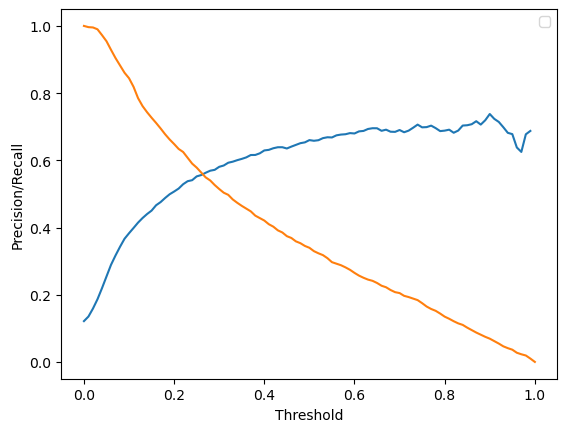

In [216]:
df_pr = prec_rec(y_pred, y_val)

In [214]:
df_pr.sort_values(by=['prec_rec_diff'])

,threshold,precision,recall,prec_rec_diff
26,0.26,0.556155,0.563752,0.007598
27,0.27,0.563025,0.549180,0.013845
25,0.25,0.552174,0.578324,0.026150
28,0.28,0.569098,0.540073,0.029025
29,0.29,0.571711,0.526412,0.045300
...,...,...,...,...
3,0.03,0.186481,0.989982,0.803500
2,0.02,0.158843,0.995446,0.836603
1,0.01,0.135095,0.996357,0.861262
0,0.00,0.121433,1.000000,0.878567


answer: 0.265 is closest

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.02
- 0.22
- 0.42
- 0.62


In [220]:
def compute_F1_score(y_pred, y_val):
    scores = []
    for t in np.linspace(0, 1, 101):
        

        pred_pos = (y_pred >= t)
        pred_neg = (y_pred < t)

        actual_pos = (y_val == 1)
        actual_neg = (y_val == 0)

        tp = (pred_pos & actual_pos).sum()
        fp = (pred_pos & actual_neg).sum()
        assert tp + fp == pred_pos.sum()
        fn = (pred_neg & actual_pos).sum()
        tn = (pred_neg & actual_neg).sum()
        assert fn + tn == pred_neg.sum()
        assert tp + fp + fn + tn == len(y_val) == len(y_pred)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        prec_rec_diff = abs(precision - recall)
        f1_score = 2 * ((precision * recall) / (precision + recall))
        scores.append((t, precision, recall, prec_rec_diff, f1_score))

    df_scores = pd.DataFrame(scores, columns=['threshold', 'precision', 'recall', 'prec_rec_diff', "f1_score"])
    # plt.plot(df_scores['threshold'], df_scores['precision'], )
    # plt.plot(df_scores['threshold'], df_scores['recall'])
    # plt.xlabel('Threshold')
    # plt.ylabel('Precision/Recall')
    # plt.legend()

    return df_scores

In [221]:
df_f1 = compute_F1_score(y_pred, y_val)
df_f1.sort_values(by=['f1_score'], ascending=False)

/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_90300/1971673488.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


,threshold,precision,recall,prec_rec_diff,f1_score
22,0.22,0.528913,0.624772,0.095859,0.572860
23,0.23,0.537903,0.607468,0.069565,0.570573
20,0.20,0.507123,0.648452,0.141329,0.569145
19,0.19,0.498970,0.662113,0.163142,0.569080
21,0.21,0.515938,0.633880,0.117942,0.568860
...,...,...,...,...,...
96,0.96,0.638298,0.027322,0.610975,0.052402
97,0.97,0.625000,0.022769,0.602231,0.043937
98,0.98,0.677419,0.019126,0.658294,0.037201
99,0.99,0.687500,0.010018,0.677482,0.019749


answer: 0.22

### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- 0.06
- 0.26

In [224]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)


In [ ]:
def split_full_train(df):
    df = df.copy()
    df_full_train, df_test = train_test_split(df, test_size=0.2, )

y
0    39922
1     5289
Name: count, dtype: int64

In [236]:
df_full_train.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome
22468,52,management,married,tertiary,0,no,cellular,22,aug,232,2,-1,0,unknown
6896,50,admin.,single,secondary,330,yes,unknown,28,may,24,1,-1,0,unknown
28408,45,blue-collar,married,primary,300,yes,cellular,29,jan,203,1,261,3,failure
8481,38,technician,married,secondary,27,yes,unknown,3,jun,404,4,-1,0,unknown
28753,31,services,single,secondary,887,no,cellular,30,jan,427,1,-1,0,unknown


In [237]:
y_full_train

array([0, 0, 0, ..., 0, 0, 0])

In [250]:
def train_cfv(df_full_train, y_full_train):
    auc_scores = []
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        y_train = y_full_train[train_idx]
        y_val = y_full_train[val_idx]

        train_dicts = df_train.to_dict(orient='records')
        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(train_dicts)
        model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
        model.fit(X_train, y_train)
        val_dicts = df_val.to_dict(orient='records')
        X_val = dv.transform(val_dicts)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        auc_scores.append(auc)

    return np.std(auc_scores)

In [251]:
train_cfv(df_full_train, y_full_train)

0.005640484377217088

answer: closest is 0.006

### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [259]:
def train_cfv_q6(df_full_train, y_full_train, C):
    auc_scores = []
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        y_train = y_full_train[train_idx]
        y_val = y_full_train[val_idx]

        train_dicts = df_train.to_dict(orient='records')
        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(train_dicts)
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)
        val_dicts = df_val.to_dict(orient='records')
        X_val = dv.transform(val_dicts)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        auc_scores.append(auc)

    mean_auc = round(np.mean(auc_scores), 3)
    std_auc = round(np.std(auc_scores), 3)
    return (mean_auc, std_auc)

In [260]:
for c in [0.000001, 0.001, 1]:
    mean_auc, std_auc = train_cfv_q6(df_full_train, y_full_train, C=c)
    print(f"C: {c} --- mean_auc: {mean_auc} --- std_auc: {std_auc}")
    

C: 1e-06 --- mean_auc: 0.701 --- std_auc: 0.009
C: 0.001 --- mean_auc: 0.861 --- std_auc: 0.007
C: 1 --- mean_auc: 0.906 --- std_auc: 0.006


answer: C of 1 leads to the best mean auc on cross validation.